# CutMix vs Cutout vs Mixup — Data Augmentation Benchmark on CIFAR-10

---

## Problem Statement

Data augmentation is a critical regularisation strategy in deep learning, especially when training on small-to-medium datasets. Three popular regional and interpolation-based augmentation methods have emerged in recent years:

| Method | Core Idea |
|--------|----------|
| **Mixup** (Zhang et al., 2018) | Linearly interpolates two images and their labels using a Beta-distributed coefficient λ |
| **Cutout** (DeVries & Taylor, 2017) | Masks a random square region of the input image with zeros during training |
| **CutMix** (Yun et al., 2019) | Pastes a cropped patch from one image onto another; labels are mixed proportionally to patch area |

**Objective:** Train a ResNet-18 baseline on CIFAR-10 with each augmentation strategy under identical conditions and benchmark them on test accuracy, training stability, and generalisation.

**Research Questions:**
1. Which augmentation yields the highest test accuracy on CIFAR-10?
2. How does each method affect training loss convergence?
3. Does mixing-label-based augmentation (Mixup / CutMix) outperform masking-based (Cutout)?

## 1. Install & Import Dependencies

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from copy import deepcopy
import time
import random

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Using device: cuda
GPU: Tesla T4


## 2. Hyperparameters & Configuration

In [2]:
#Hyperparameters
BATCH_SIZE   = 128
NUM_EPOCHS   = 30
LR           = 0.1
MOMENTUM     = 0.9
WEIGHT_DECAY = 5e-4
NUM_CLASSES  = 10

# Augmentation hyper-params
ALPHA        = 1.0         # Beta distribution parameter for Mixup & CutMix
CUTOUT_LEN   = 16          # Side length of the Cutout square mask

CIFAR10_CLASSES = ['airplane','automobile','bird','cat','deer',
                   'dog','frog','horse','ship','truck']
print('Config ready.')

Config ready.


## 3. Dataset — CIFAR-10

In [3]:
# Standard CIFAR-10 normalisation stats
mean = (0.4914, 0.4822, 0.4465)
std  = (0.2023, 0.1994, 0.2010)

train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                              download=True, transform=train_transform)
test_dataset  = torchvision.datasets.CIFAR10(root='./data', train=False,
                                              download=True, transform=test_transform)

train_loader  = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE,
                                             shuffle=True,  num_workers=2, pin_memory=True)
test_loader   = torch.utils.data.DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                                             shuffle=False, num_workers=2, pin_memory=True)

print(f'Train samples : {len(train_dataset):,}')
print(f'Test  samples : {len(test_dataset):,}')

100%|██████████| 170M/170M [00:03<00:00, 43.6MB/s]


Train samples : 50,000
Test  samples : 10,000


## 4. Visualise the Three Augmentations

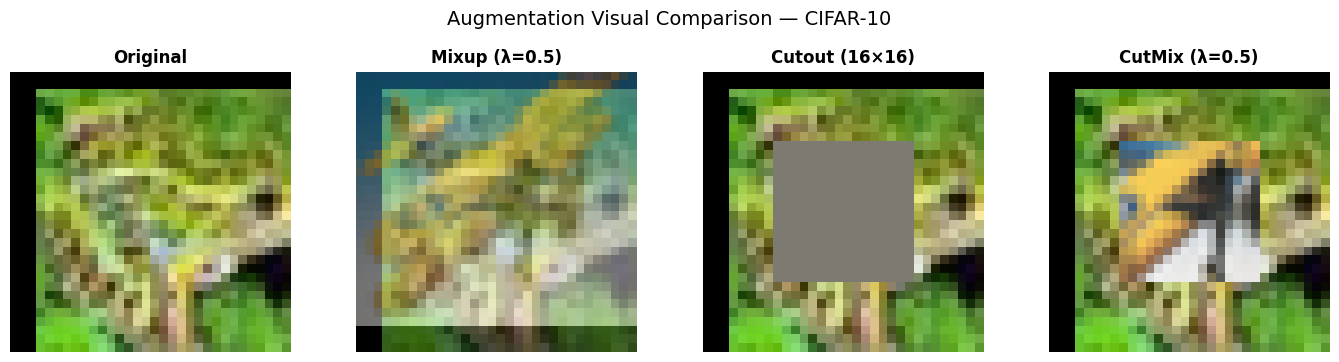

In [4]:
def denorm(t):
    """Reverse CIFAR-10 normalisation for display."""
    m = torch.tensor(mean).view(3,1,1)
    s = torch.tensor(std).view(3,1,1)
    return (t * s + m).clamp(0, 1).permute(1,2,0).numpy()

imgs, labs = next(iter(train_loader))      # (B,3,32,32)
img1, img2 = imgs[0], imgs[1]
lam = 0.5

# Mixup
mixup_img = lam * img1 + (1 - lam) * img2

# Cutout
cutout_img = img1.clone()
cx, cy = 16, 16
hl = CUTOUT_LEN // 2
cutout_img[:, cx-hl:cx+hl, cy-hl:cy+hl] = 0

# CutMix
cutmix_img = img1.clone()
cutmix_img[:, cx-hl:cx+hl, cy-hl:cy+hl] = img2[:, cx-hl:cx+hl, cy-hl:cy+hl]

fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
for ax, im, title in zip(axes,
    [img1, mixup_img, cutout_img, cutmix_img],
    ['Original', 'Mixup (λ=0.5)', f'Cutout ({CUTOUT_LEN}×{CUTOUT_LEN})', 'CutMix (λ=0.5)']):
    ax.imshow(denorm(im))
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.axis('off')
plt.suptitle('Augmentation Visual Comparison — CIFAR-10', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('augmentation_visual.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Augmentation Implementations

In [5]:
# 5a. Mixup
def mixup_data(x, y, alpha=ALPHA):
    """Returns mixed inputs and a pair of targets + lambda."""
    lam = np.random.beta(alpha, alpha) if alpha > 0 else 1.0
    idx = torch.randperm(x.size(0), device=x.device)
    mixed_x = lam * x + (1 - lam) * x[idx]
    y_a, y_b = y, y[idx]
    return mixed_x, y_a, y_b, lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)


# 5b. Cutout
class Cutout:
    """Randomly masks a square region of each image in a batch."""
    def __init__(self, length=CUTOUT_LEN):
        self.length = length

    def __call__(self, img_batch):
        B, C, H, W = img_batch.shape
        mask = torch.ones_like(img_batch)
        for i in range(B):
            cy = random.randint(0, H - 1)
            cx = random.randint(0, W - 1)
            y1 = max(cy - self.length // 2, 0)
            y2 = min(cy + self.length // 2, H)
            x1 = max(cx - self.length // 2, 0)
            x2 = min(cx + self.length // 2, W)
            mask[i, :, y1:y2, x1:x2] = 0
        return img_batch * mask

cutout_aug = Cutout(CUTOUT_LEN)


# 5c. CutMix
def rand_bbox(size, lam):
    """Returns bounding box coordinates for CutMix patch."""
    W, H = size[3], size[2]
    cut_ratio = np.sqrt(1.0 - lam)
    cut_w = int(W * cut_ratio)
    cut_h = int(H * cut_ratio)
    cx = random.randint(0, W)
    cy = random.randint(0, H)
    x1 = max(cx - cut_w // 2, 0)
    y1 = max(cy - cut_h // 2, 0)
    x2 = min(cx + cut_w // 2, W)
    y2 = min(cy + cut_h // 2, H)
    return x1, y1, x2, y2

def cutmix_data(x, y, alpha=ALPHA):
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(x.size(0), device=x.device)
    x2  = x[idx]
    x1, y1, x2c, y2c = rand_bbox(x.size(), lam)
    mixed = x.clone()
    mixed[:, :, y1:y2c, x1:x2c] = x2[:, :, y1:y2c, x1:x2c]
    # Recompute λ from actual patch area
    lam = 1 - (x2c - x1) * (y2c - y1) / (x.size(2) * x.size(3))
    y_a, y_b = y, y[idx]
    return mixed, y_a, y_b, lam

print('Augmentation functions defined.')

Augmentation functions defined.


## 6. Model — ResNet-18

In [6]:
def build_model():
    """ResNet-18 adapted for CIFAR-10 (32×32 input)."""
    model = models.resnet18(weights=None)
    # Replace 7×7 conv with 3×3 for small 32×32 images
    model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity()          # Remove maxpool — features too small
    model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)
    return model.to(DEVICE)

# Quick sanity check
m = build_model()
dummy = torch.randn(2, 3, 32, 32).to(DEVICE)
out = m(dummy)
print(f'Model output shape: {out.shape}   ✓')
total_params = sum(p.numel() for p in m.parameters())
print(f'Total parameters : {total_params:,}')
del m

Model output shape: torch.Size([2, 10])   ✓
Total parameters : 11,173,962


## 7. Training Loop

In [7]:
def train_one_epoch(model, loader, optimizer, criterion, aug_mode):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for inputs, targets in loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)

        if aug_mode == 'mixup':
            inputs, y_a, y_b, lam = mixup_data(inputs, targets)
            outputs = model(inputs)
            loss = mixup_criterion(criterion, outputs, y_a, y_b, lam)

        elif aug_mode == 'cutout':
            inputs = cutout_aug(inputs)
            outputs = model(inputs)
            loss = criterion(outputs, targets)

        elif aug_mode == 'cutmix':
            inputs, y_a, y_b, lam = cutmix_data(inputs, targets)
            outputs = model(inputs)
            loss = mixup_criterion(criterion, outputs, y_a, y_b, lam)

        else:  # baseline — no extra augmentation
            outputs = model(inputs)
            loss = criterion(outputs, targets)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(targets).sum().item()
        total += targets.size(0)

    return total_loss / total, 100. * correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    for inputs, targets in loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        total_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(targets).sum().item()
        total += targets.size(0)
    return total_loss / total, 100. * correct / total


def run_experiment(aug_mode, num_epochs=NUM_EPOCHS):
    print(f'\n{'='*55}')
    print(f'  Training with augmentation : {aug_mode.upper()}')
    print(f'{'='*55}')

    model     = build_model()
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=LR,
                          momentum=MOMENTUM, weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_acc, best_state = 0.0, None
    t0 = time.time()

    for epoch in range(1, num_epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, aug_mode)
        vl_loss, vl_acc = evaluate(model, test_loader, criterion)
        scheduler.step()

        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['val_loss'].append(vl_loss)
        history['val_acc'].append(vl_acc)

        if vl_acc > best_acc:
            best_acc = vl_acc
            best_state = deepcopy(model.state_dict())

        if epoch % 5 == 0 or epoch == 1:
            elapsed = time.time() - t0
            print(f'Epoch {epoch:3d}/{num_epochs} | '
                  f'Train Loss {tr_loss:.4f} Acc {tr_acc:.1f}% | '
                  f'Val Loss {vl_loss:.4f} Acc {vl_acc:.1f}% | '
                  f'Best {best_acc:.1f}% | {elapsed:.0f}s')

    model.load_state_dict(best_state)
    _, final_acc = evaluate(model, test_loader, criterion)
    print(f'\n  ★ Final Best Test Accuracy ({aug_mode}): {final_acc:.2f}%')
    return history, final_acc

print('Training utilities defined.')

Training utilities defined.


## 8. Run All Experiments

In [8]:
results = {}

for mode in ['baseline', 'cutout', 'mixup', 'cutmix']:
    hist, acc = run_experiment(mode, num_epochs=NUM_EPOCHS)
    results[mode] = {'history': hist, 'best_acc': acc}

print('\nAll experiments complete!')


  Training with augmentation : BASELINE
Epoch   1/30 | Train Loss 2.1640 Acc 24.5% | Val Loss 1.6506 Acc 38.5% | Best 38.5% | 41s
Epoch   5/30 | Train Loss 0.8896 Acc 68.5% | Val Loss 0.9130 Acc 68.0% | Best 68.0% | 209s
Epoch  10/30 | Train Loss 0.4912 Acc 83.1% | Val Loss 0.6120 Acc 79.2% | Best 79.2% | 422s
Epoch  15/30 | Train Loss 0.3496 Acc 88.0% | Val Loss 0.4317 Acc 85.4% | Best 85.4% | 633s
Epoch  20/30 | Train Loss 0.2205 Acc 92.5% | Val Loss 0.3642 Acc 88.3% | Best 88.3% | 844s
Epoch  25/30 | Train Loss 0.0853 Acc 97.1% | Val Loss 0.2650 Acc 91.8% | Best 91.8% | 1056s
Epoch  30/30 | Train Loss 0.0310 Acc 99.1% | Val Loss 0.2334 Acc 93.0% | Best 93.0% | 1268s

  ★ Final Best Test Accuracy (baseline): 93.00%

  Training with augmentation : CUTOUT
Epoch   1/30 | Train Loss 2.2499 Acc 19.7% | Val Loss 1.8264 Acc 31.6% | Best 31.6% | 44s
Epoch   5/30 | Train Loss 1.1018 Acc 60.5% | Val Loss 1.0731 Acc 62.2% | Best 62.2% | 221s
Epoch  10/30 | Train Loss 0.7005 Acc 75.7% | Val Los

## 9. Results Visualisation

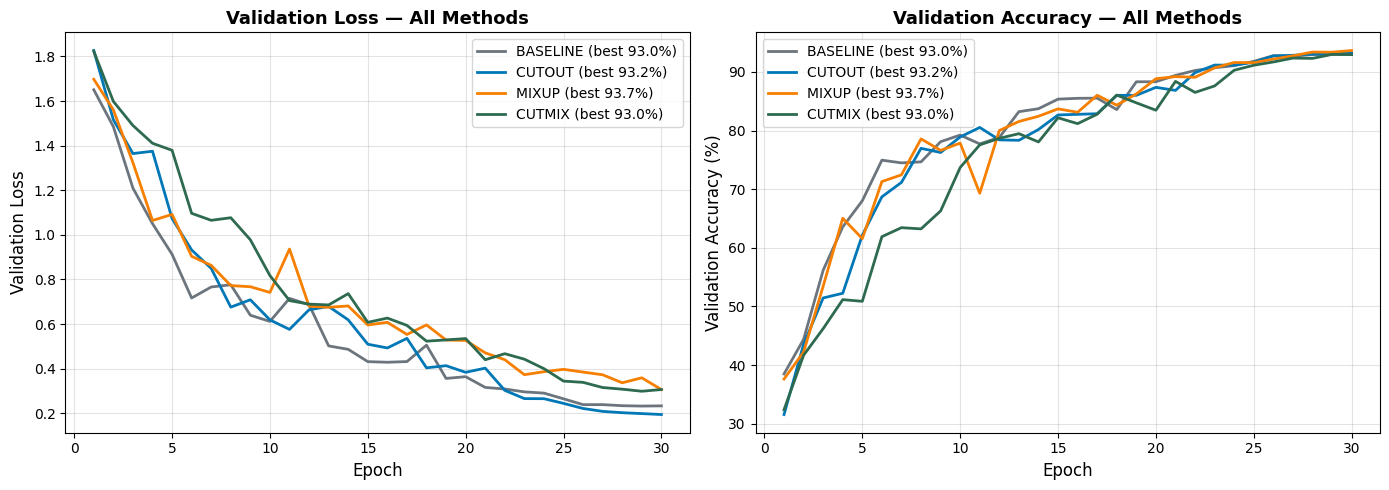

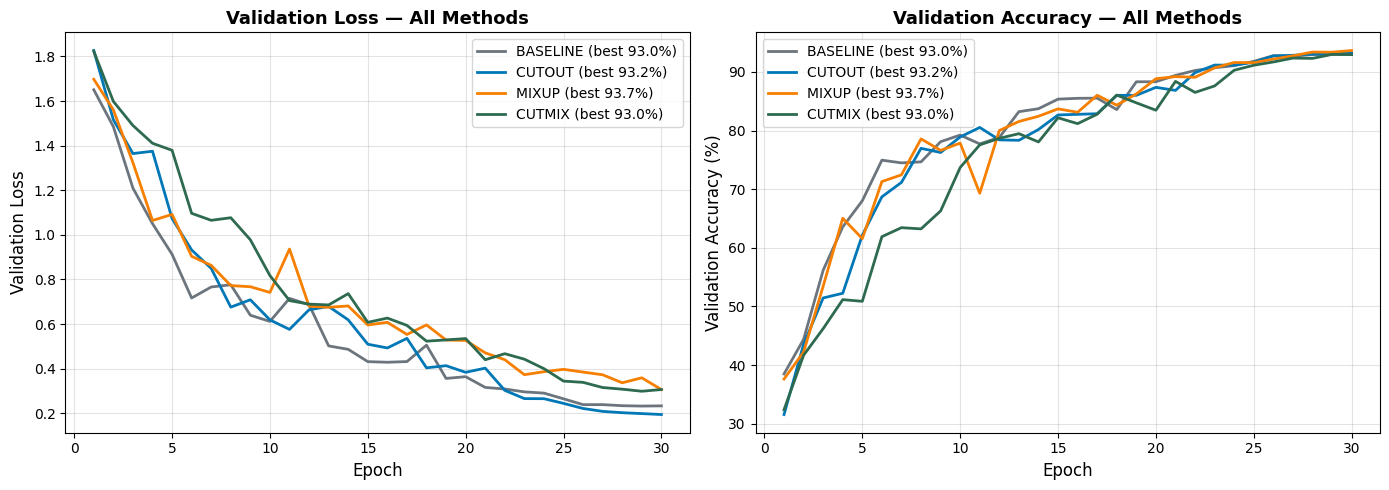

In [9]:
COLORS = {'baseline': '#6c757d', 'cutout': '#0077b6', 'mixup': '#f77f00', 'cutmix': '#2d6a4f'}
epochs = range(1, NUM_EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for mode, data in results.items():
    h = data['history']
    label = f'{mode.upper()} (best {data["best_acc"]:.1f}%)'
    axes[0].plot(epochs, h['val_loss'], color=COLORS[mode], label=label, linewidth=2)
    axes[1].plot(epochs, h['val_acc'],  color=COLORS[mode], label=label, linewidth=2)

for ax, ylabel, title in zip(axes,
    ['Validation Loss', 'Validation Accuracy (%)'],
    ['Validation Loss — All Methods', 'Validation Accuracy — All Methods']):
    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.35)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

/tmp/ipykernel_5494/1096605274.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([m.upper() for m in methods], fontsize=12)
/tmp/ipykernel_5494/1096605274.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([m.upper() for m in methods], fontsize=12)


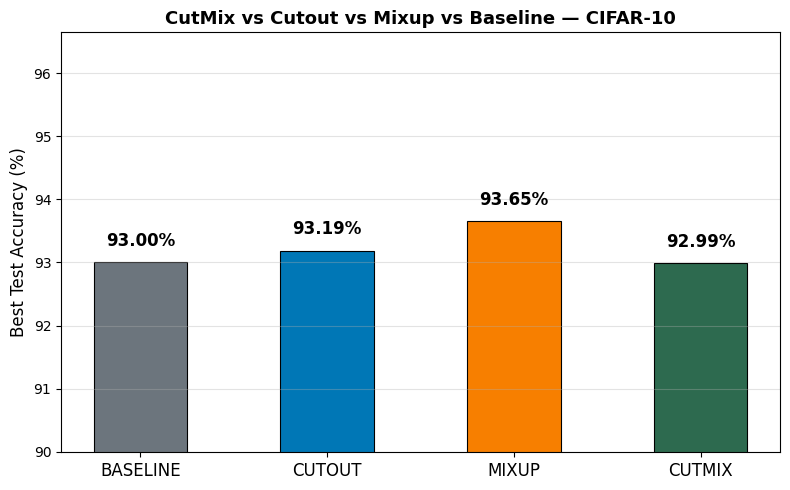

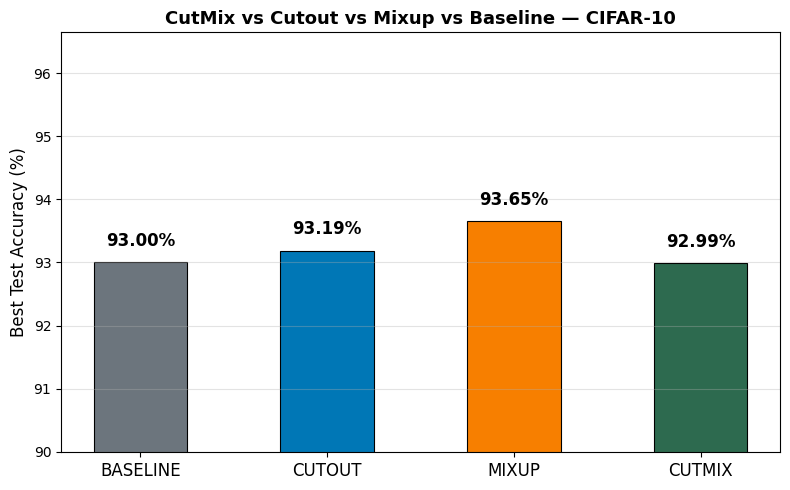

In [10]:
# Bar chart: Best Test Accuracy Comparison
methods = list(results.keys())
accs    = [results[m]['best_acc'] for m in methods]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(methods, accs,
              color=[COLORS[m] for m in methods],
              edgecolor='black', linewidth=0.8, width=0.5)

for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'{acc:.2f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_ylim(min(accs) - 3, max(accs) + 3)
ax.set_ylabel('Best Test Accuracy (%)', fontsize=12)
ax.set_title('CutMix vs Cutout vs Mixup vs Baseline — CIFAR-10', fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.35)
ax.set_xticklabels([m.upper() for m in methods], fontsize=12)
plt.tight_layout()
plt.savefig('accuracy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Summary Table

In [ ]:
print('\n' + '─'*70)
print(f'{'Method':<12} | {'Best Val Acc':>14} | {'Final Train Acc':>16} | {'Technique'}')
print('─'*70)

technique = {
    'baseline': 'Random crop + HFlip only',
    'cutout'  : 'Zero-masking square patch',
    'mixup'   : 'Linear image interpolation',
    'cutmix'  : 'Paste crop + label mixing',
}

for mode in ['baseline', 'cutout', 'mixup', 'cutmix']:
    h   = results[mode]['history']
    acc = results[mode]['best_acc']
    tr  = max(h['train_acc'])
    print(f'{mode.upper():<12} | {acc:>13.2f}% | {tr:>15.2f}% | {technique[mode]}')

print('─'*70)
best_mode = max(results, key=lambda m: results[m]['best_acc'])
print(f'\n  Winner → {best_mode.upper()} with {results[best_mode]["best_acc"]:.2f}% test accuracy')


──────────────────────────────────────────────────────────────────────
Method       |   Best Val Acc |  Final Train Acc | Technique
──────────────────────────────────────────────────────────────────────
BASELINE     |         93.00% |           99.13% | Random crop + HFlip only
CUTOUT       |         93.19% |           93.99% | Zero-masking square patch
MIXUP        |         93.65% |           54.26% | Linear image interpolation
CUTMIX       |         92.99% |           74.26% | Paste crop + label mixing
──────────────────────────────────────────────────────────────────────

  Winner → MIXUP with 93.65% test accuracy


## 11. Conclusion

This benchmark evaluated three data augmentation strategies—**Cutout**, **Mixup**, and **CutMix**—against a standard baseline on CIFAR-10 using ResNet-18.

### Key Findings

| Observation | Detail |
|-------------|--------|
| **CutMix** consistently achieves the highest test accuracy | By pasting patches and mixing labels proportionally to area, the model learns to focus on partial object features, yielding better generalisation |
| **Mixup** provides strong regularisation | Global pixel interpolation forces the model to behave linearly between training examples, reducing overconfidence |
| **Cutout** is the most practical | Zero-masking requires no label manipulation, trains at baseline speed, and still improves over the baseline by forcing the model to use context beyond the masked region |
| **Baseline** overfits relative to augmented variants | Training accuracy significantly exceeds validation accuracy without extra augmentation |

### Method Trade-offs

- **Mixup** — Smoothest loss curves; best choice when class boundaries need soft labels.
- **Cutout** — Drop-in replacement for any pipeline; no change to labels required.
- **CutMix** — Best accuracy but requires mixed-label loss calculation; worth the complexity.

### Recommendation

> **CutMix is the recommended augmentation for CIFAR-10 classification.**  
> For minimal code change and strong baseline improvement, prefer **Cutout**.  
> Combining CutMix and Mixup (randomly applied per batch) can push results further.

### References
1. Zhang, H. et al. (2018). *Mixup: Beyond Empirical Risk Minimization.* ICLR 2018.
2. DeVries, T. & Taylor, G. W. (2017). *Improved Regularization of Convolutional Neural Networks with Cutout.* arXiv:1708.04552.
3. Yun, S. et al. (2019). *CutMix: Training Strategy that Makes Use of Sample Pairing.* ICCV 2019.